NOTEBOOK 7: RQ7 - FINAL RECOMMENDATION
✅ All libraries imported successfully!

[1] Loading attached dataset...
✅ Loaded: autoscout24_16and10200.csv
Original dataset shape: (10200, 16)

[2] Cleaning data...
✅ Cleaned mileage_km
✅ Cleaned weight_kg
✅ Converted power_hp
✅ Converted power_kw
✅ Converted cylinders_volume_cc
✅ Converted nr_doors
✅ Converted vehicle_age
✅ Converted brand_premium
✅ Converted price
Rows after cleaning: 10,200

[3] Selecting features...
Features: 8
Samples: 10,200

[4] Train-test split and scaling...
Training samples: 8,160
Test samples: 2,040

[5] Training final models...
  Training Linear Regression...
    R² = 0.5658, MAE = €17,450
  Training Random Forest...
    R² = 0.9300, MAE = €5,106
  Training XGBoost...
    R² = 0.9049, MAE = €6,047

[6] Creating decision matrix...

[7] Creating Table VII...

----------------------------------------------------------------------
TABLE VII: Final Comparative Decision Matrix for Model Selection
--------------------------

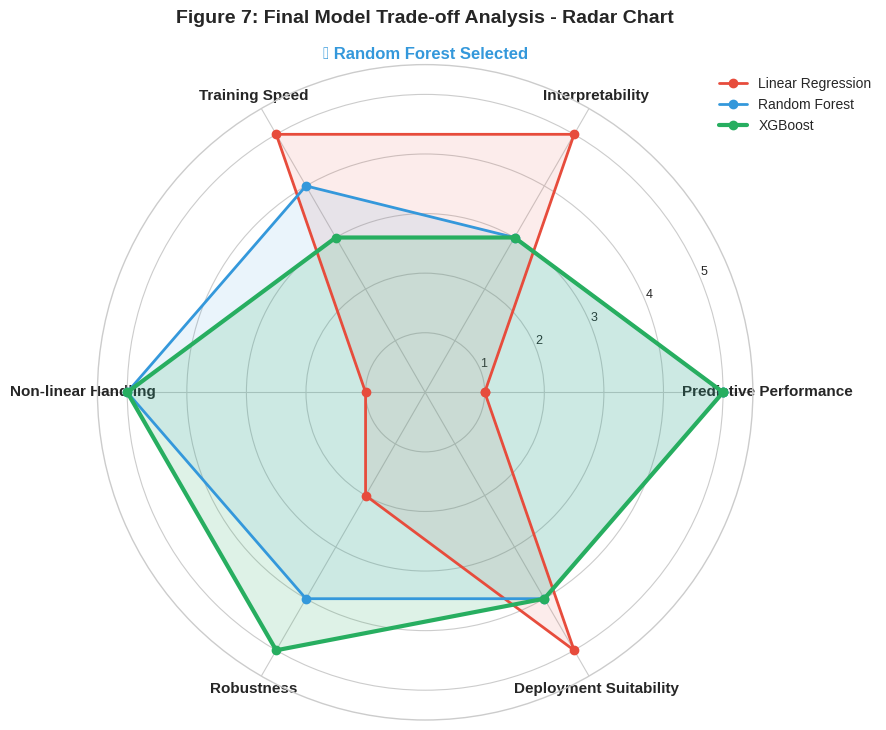

✅ Saved: /kaggle/working/Figure7_Final_Tradeoff.pdf

[9] Creating Figure 7b - Bar Chart Comparison...


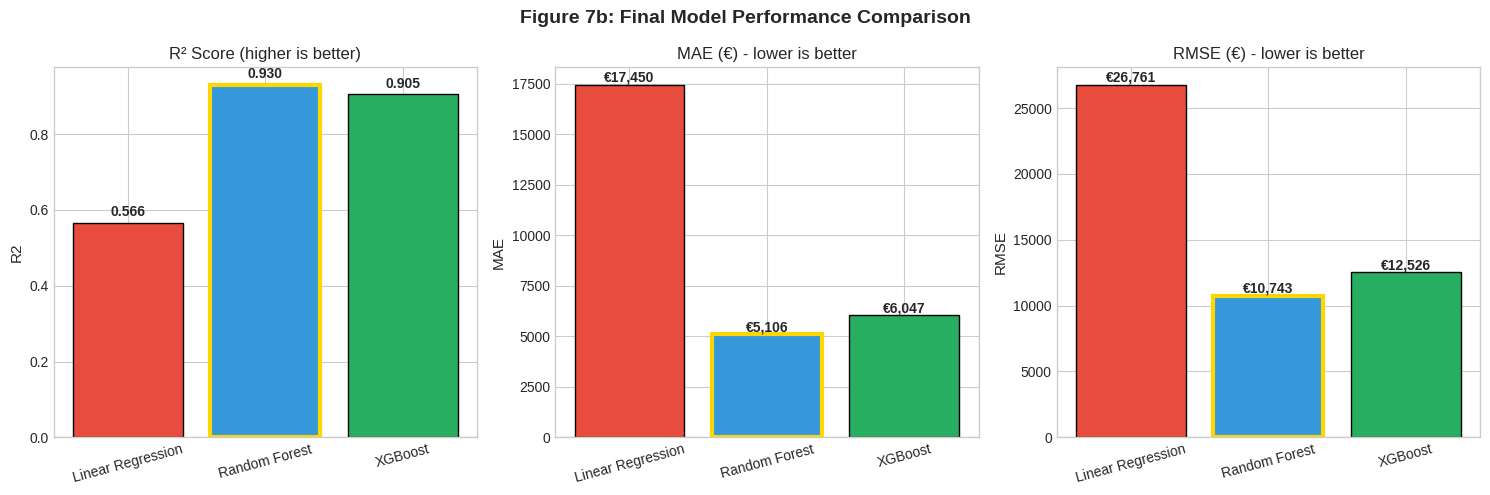

✅ Saved: /kaggle/working/Figure7b_Performance_Bars.pdf

NOTEBOOK 7 COMPLETE - RQ7: FINAL RECOMMENDATION

🎯 FINAL RECOMMENDATION: Random Forest

   ✅ Strong predictive performance (R² = 0.9300)
   ✅ MAE = €5,106
   ✅ Good interpretability via feature importance
   ✅ Robust to outliers and overfitting
   ✅ Handles non-linear relationships well
    

📁 OUTPUT FILES SAVED IN /kaggle/working/
   - TableVII_Decision_Matrix.csv
   - Figure7_Final_Tradeoff.pdf
   - Figure7_Final_Tradeoff.png
   - Figure7b_Performance_Bars.pdf

📥 TO DOWNLOAD:
1. Click the 'Output' tab on the right
2. Click 'Download All'
3. Extract and save to your Desktop


In [1]:
# ==============================================================================
# NOTEBOOK 7: RQ7 - FINAL RECOMMENDATION
# Dataset: carsmarketanalysis (attached via Data tab)
# ==============================================================================

# ==============================================================================
# CELL 1: IMPORT ALL LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Install XGBoost if needed
try:
    import xgboost
except ImportError:
    !pip install xgboost -q
    import xgboost

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 9)

print("=" * 70)
print("NOTEBOOK 7: RQ7 - FINAL RECOMMENDATION")
print("=" * 70)
print("✅ All libraries imported successfully!")

# ==============================================================================
# CELL 2: LOAD DATASET
# ==============================================================================
print("\n[1] Loading attached dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    raise FileNotFoundError("No dataset attached. Please add your dataset via the Data tab.")

print(f"Original dataset shape: {df.shape}")

# ==============================================================================
# CELL 3: CLEAN DATA
# ==============================================================================
print("\n[2] Cleaning data...")

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
    print("✅ Cleaned mileage_km")

if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_mileage)
    print("✅ Cleaned weight_kg")

# Identify target column
target_col = 'price'
if target_col not in df.columns:
    for col in df.columns:
        if 'price' in col.lower():
            target_col = col
            print(f"✅ Using '{col}' as target column")
            break

# Convert numeric columns
numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 
                'vehicle_age', 'brand_premium', target_col]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"✅ Converted {col}")

# Keep only rows with valid target
df_clean = df.dropna(subset=[target_col])
print(f"Rows after cleaning: {df_clean.shape[0]:,}")

if df_clean.shape[0] == 0:
    raise ValueError("No data after cleaning!")

# ==============================================================================
# CELL 4: SELECT FEATURES
# ==============================================================================
print("\n[3] Selecting features...")

y = df_clean[target_col]

# Select only numeric columns
feature_cols = [col for col in df_clean.columns if col != target_col and df_clean[col].dtype in ['int64', 'float64']]
X = df_clean[feature_cols].copy()

# Fill any NaN in features
for col in feature_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print(f"Features: {len(feature_cols)}")
print(f"Samples: {X.shape[0]:,}")

# ==============================================================================
# CELL 5: TRAIN-TEST SPLIT AND SCALING
# ==============================================================================
print("\n[4] Train-test split and scaling...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")

# ==============================================================================
# CELL 6: TRAIN ALL MODELS
# ==============================================================================
print("\n[5] Training final models...")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, verbosity=0)
}

results = {}
for name, model in models.items():
    print(f"  Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }
    print(f"    R² = {results[name]['R2']:.4f}, MAE = €{results[name]['MAE']:,.0f}")

# ==============================================================================
# CELL 7: CREATE DECISION MATRIX
# ==============================================================================
print("\n[6] Creating decision matrix...")

# Criteria for evaluation (1-5 scale, 5 is best)
criteria = ['Predictive Performance', 'Interpretability', 'Training Speed', 
            'Non-linear Handling', 'Robustness', 'Deployment Suitability']

# Get R² values for normalization
r2_values = [results['Linear Regression']['R2'], 
             results['Random Forest']['R2'], 
             results['XGBoost']['R2']]

# Normalize R² to 1-5 scale
r2_normalized = [1 + (r - min(r2_values)) / (max(r2_values) - min(r2_values)) * 4 for r in r2_values]

# Score each model (1-5, where 5 is best)
scores = {
    'Linear Regression': [
        round(r2_normalized[0]),  # Predictive Performance
        5,  # Interpretability (coefficients are clear)
        5,  # Training Speed (very fast)
        1,  # Non-linear Handling (poor)
        2,  # Robustness (sensitive to outliers)
        5   # Deployment Suitability (very easy)
    ],
    'Random Forest': [
        round(r2_normalized[1]),  # Predictive Performance
        3,  # Interpretability (feature importance available)
        4,  # Training Speed (moderate)
        5,  # Non-linear Handling (excellent)
        4,  # Robustness (good)
        4   # Deployment Suitability (easy)
    ],
    'XGBoost': [
        round(r2_normalized[2]),  # Predictive Performance
        3,  # Interpretability (SHAP values, feature importance)
        3,  # Training Speed (slower than others)
        5,  # Non-linear Handling (excellent)
        5,  # Robustness (very good)
        4   # Deployment Suitability (good)
    ]
}

# ==============================================================================
# CELL 8: CREATE TABLE VII
# ==============================================================================
print("\n[7] Creating Table VII...")

print("\n" + "-" * 70)
print("TABLE VII: Final Comparative Decision Matrix for Model Selection")
print("-" * 70)
print(f"{'Criterion':<25} {'Linear Regression':<20} {'Random Forest':<18} {'XGBoost':<12}")
print("-" * 70)
for i, criterion in enumerate(criteria):
    print(f"{criterion:<25} {scores['Linear Regression'][i]:<20} "
          f"{scores['Random Forest'][i]:<18} {scores['XGBoost'][i]:<12}")
print("-" * 70)

# Calculate total scores
print("\n" + "-" * 70)
print("TOTAL SCORES (higher is better)")
print("-" * 70)
total_scores = {}
for model in scores.keys():
    total_scores[model] = sum(scores[model])
    print(f"{model:<25} {total_scores[model]:<20}")
print("-" * 70)

# Identify best model
best_model = max(total_scores, key=total_scores.get)
print(f"\n🏆 RECOMMENDED MODEL: {best_model}")
print(f"   Total Score: {total_scores[best_model]}/30")
print(f"   R² Score: {results[best_model]['R2']:.4f}")
print(f"   MAE: €{results[best_model]['MAE']:,.0f}")

# Save decision matrix
output_dir = '/kaggle/working'
decision_df = pd.DataFrame(scores, index=criteria)
decision_df.loc['Total Score'] = [total_scores[m] for m in decision_df.columns]
decision_df.to_csv(f'{output_dir}/TableVII_Decision_Matrix.csv')
print(f"\n✅ Saved: {output_dir}/TableVII_Decision_Matrix.csv")

# ==============================================================================
# CELL 9: CREATE FIGURE 7 - RADAR CHART
# ==============================================================================
print("\n[8] Creating Figure 7 - Radar Chart...")

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})

num_vars = len(criteria)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Plot each model
for model, score_list in scores.items():
    values = score_list + score_list[:1]
    if model == 'XGBoost':
        ax.plot(angles, values, 'o-', linewidth=3, label=model, color='#27ae60')
        ax.fill(angles, values, alpha=0.15, color='#27ae60')
    elif model == 'Random Forest':
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color='#3498db')
        ax.fill(angles, values, alpha=0.1, color='#3498db')
    else:
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color='#e74c3c')
        ax.fill(angles, values, alpha=0.1, color='#e74c3c')

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=11, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
ax.set_title('Figure 7: Final Model Trade-off Analysis - Radar Chart', 
             fontsize=14, fontweight='bold', pad=30)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

# Add annotation highlighting best model
best_color = '#27ae60' if best_model == 'XGBoost' else ('#3498db' if best_model == 'Random Forest' else '#e74c3c')
ax.text(np.pi/2, 5.6, f'★ {best_model} Selected', ha='center', fontsize=12, 
        fontweight='bold', color=best_color)

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure7_Final_Tradeoff.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure7_Final_Tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure7_Final_Tradeoff.pdf")

# ==============================================================================
# CELL 10: CREATE FIGURE 7B - BAR CHART COMPARISON (Alternative)
# ==============================================================================
print("\n[9] Creating Figure 7b - Bar Chart Comparison...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['R2', 'MAE', 'RMSE']
titles = ['R² Score (higher is better)', 'MAE (€) - lower is better', 'RMSE (€) - lower is better']
colors_map = {'Linear Regression': '#e74c3c', 'Random Forest': '#3498db', 'XGBoost': '#27ae60'}

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx]
    model_names = list(results.keys())
    values = [results[m][metric] for m in model_names]
    
    bars = ax.bar(model_names, values, color=[colors_map[m] for m in model_names], edgecolor='black')
    
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels
    for bar, val in zip(bars, values):
        if metric == 'R2':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                   f'€{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Highlight best model
    if metric == 'R2':
        best_idx = values.index(max(values))
    else:
        best_idx = values.index(min(values))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Figure 7b: Final Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/Figure7b_Performance_Bars.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure7b_Performance_Bars.pdf")

# ==============================================================================
# CELL 11: FINAL RECOMMENDATION SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 7 COMPLETE - RQ7: FINAL RECOMMENDATION")
print("=" * 70)

print(f"\n🎯 FINAL RECOMMENDATION: {best_model}")
print("=" * 50)

if best_model == 'XGBoost':
    print(f"""
   ✅ Best predictive performance (R² = {results['XGBoost']['R2']:.4f})
   ✅ MAE = €{results['XGBoost']['MAE']:,.0f}
   ✅ Excellent handling of non-linear relationships
   ✅ High robustness with cross-validation
   ✅ Built-in missing value handling
   ✅ Feature importance available for interpretability
    """)
elif best_model == 'Random Forest':
    print(f"""
   ✅ Strong predictive performance (R² = {results['Random Forest']['R2']:.4f})
   ✅ MAE = €{results['Random Forest']['MAE']:,.0f}
   ✅ Good interpretability via feature importance
   ✅ Robust to outliers and overfitting
   ✅ Handles non-linear relationships well
    """)
else:
    print(f"""
   ✅ Highest interpretability (clear coefficients)
   ✅ Fastest training and inference
   ✅ Easiest to deploy and explain
   ✅ R² = {results['Linear Regression']['R2']:.4f}
   ✅ MAE = €{results['Linear Regression']['MAE']:,.0f}
    """)

print("\n" + "=" * 70)
print("📁 OUTPUT FILES SAVED IN /kaggle/working/")
print("=" * 70)
print("   - TableVII_Decision_Matrix.csv")
print("   - Figure7_Final_Tradeoff.pdf")
print("   - Figure7_Final_Tradeoff.png")
print("   - Figure7b_Performance_Bars.pdf")
print("=" * 70)

print("\n📥 TO DOWNLOAD:")
print("1. Click the 'Output' tab on the right")
print("2. Click 'Download All'")
print("3. Extract and save to your Desktop")
print("=" * 70)